# Route-3 Synthetic Cortical-Observable Recovery Preflight

This notebook asks a deliberately narrow question: do eight model parameters

`mue, mui, b, tauA, g_LK, g_h, c_th2ctx, c_ctx2th`

produce numerically stable and locally distinguishable changes in explicitly
declared **synthetic cortical observables**?

## Scientific boundary

- `r_mean_EXC` and `r_mean_INH` are cortical population firing rates in Hz, not simulated EEG.
- ALN current/synaptic states are privileged model-internal observables, not scalp measurements.
- No 75-uV rule, EEG channel semantics, arbitrary Hz-to-uV scaling, real-EEG feature selection, posterior training, or real-EEG inference is used.
- A full-rank local Jacobian is necessary evidence for local identifiability at a center, but is not proof of global recovery, calibration, or a valid posterior.
- The 64-point Sobol set is a `diagnostic_microbank`, never an SNPE training bank.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
import hashlib
import importlib.metadata as mdist
import json
import os
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in Path.cwd().resolve().parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sleep_sbi.route3_synthetic_preflight import (
    AUGMENTED_FEATURES,
    HELD_OUT_DIAGNOSTICS,
    PARAMETER_NAMES,
    RATE_ONLY_FEATURES,
    RELATIVE_SINGULAR_VALUE_THRESHOLD,
    RESULTS_ROOT,
    SCHEMA_VERSION,
    analyze_local_sensitivity,
    export_core_contract,
    feature_dictionary,
    feature_redundancy,
    local_stability_gate,
    parameter_contract,
    parameter_table,
    run_diagnostic_microbank,
    run_local_sensitivity,
)

OUTPUT_DIR = RESULTS_ROOT
FIGURE_DIR = OUTPUT_DIR / "figures"
HTML_DIR = OUTPUT_DIR / "html"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
HTML_DIR.mkdir(parents=True, exist_ok=True)

packages = {}
for package in ("numpy", "scipy", "pandas", "matplotlib", "neurolib", "torch", "sbi", "nbformat"):
    try:
        packages[package] = mdist.version(package)
    except mdist.PackageNotFoundError:
        packages[package] = "not installed"

environment = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "working_directory": str(Path.cwd()),
    "project_root": str(PROJECT_ROOT),
    "conda_default_env": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys_executable": sys.executable,
    "sys_prefix": sys.prefix,
    "python_version": platform.python_version(),
    "kernel_id": "neurolib",
    "kernel_display_name": "Python (neurolib)",
    "packages": packages,
}
assert Path(sys.executable).resolve() == Path(
    r"C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe"
).resolve()
assert Path(sys.prefix).name.lower() == "neurolib"
(OUTPUT_DIR / "environment_report.json").write_text(
    json.dumps(environment, indent=2), encoding="utf-8"
)
pd.DataFrame(
    [{"item": key, "value": value} for key, value in environment.items() if key != "packages"]
)

,item,value
0,created_utc,2026-07-27T17:24:51.851474+00:00
1,working_directory,D:\Year3_Mao_Projects\sleep_loop\S4_sbi\notebooks
2,project_root,D:\Year3_Mao_Projects\sleep_loop
3,conda_default_env,neurolib
4,sys_executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
5,sys_prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
6,python_version,3.10.20
7,kernel_id,neurolib
8,kernel_display_name,Python (neurolib)


## 1. Freeze the eight-parameter contract

The latest V8a uniform box is used for prior-wide diagnostics because its
`c_th2ctx` upper bound (0.075) contains V7, V8, and the V8a local-best center.
V7's historical upper bound was 0.05. The parameter order is never inferred
from dictionary iteration.

The simulator integrates at 0.1 ms, records at 1 ms (1000 Hz), runs for 60 s,
removes 5 s warm-up, analyzes the first complete native 30-s window, and leaves
25 s unused. Fixed simulator seed 42 supplies common random numbers across the
finite differences. Failed or non-finite runs retain theta and use invalid/NaN
features with an explicit reason; undefined values are never filled with zero.

In [2]:
contract_paths = export_core_contract()
contract = parameter_contract()
parameters = parameter_table()
assert tuple(contract["parameter_names"]) == PARAMETER_NAMES
assert len(PARAMETER_NAMES) == 8
assert all(center["inside_v8a_prior"] for center in contract["centers"])
display(parameters)
display(pd.DataFrame(contract["centers"]).drop(columns="theta"))
print("Contract hash:", contract["contract_hash"])
print("All V7/V8/V8a centers inside V8a prior:", all(c["inside_v8a_prior"] for c in contract["centers"]))

,index,parameter,unit,prior_type,lower,upper,width,v7_fitted,v8_fitted,v8a_local_best
0,0,mue,mV/ms,uniform,3.31075,4.47925,1.1685,3.801329,4.151310,3.521318
1,1,mui,mV/ms,uniform,2.57295,3.48105,0.9081,2.724747,2.719276,2.885064
2,2,b,pA,uniform,28.40000,42.60000,14.2000,42.548128,32.472799,35.851259
3,3,tauA,ms,uniform,998.20000,1853.80000,855.6000,1042.897340,1418.554270,1220.029899
4,4,g_LK,mS/cm^2,uniform,0.02000,0.07000,0.0500,0.052266,0.051219,0.050246
5,5,g_h,mS/cm^2,uniform,0.03500,0.09500,0.0600,0.066072,0.053043,0.054287
6,6,c_th2ctx,dimensionless coupling,uniform,0.00000,0.07500,0.0750,0.012676,0.029332,0.067380
7,7,c_ctx2th,dimensionless coupling,uniform,0.05000,0.22000,0.1700,0.056227,0.131831,0.125349


,identifier,model_version,source,inside_v8a_prior,outside_parameters
0,v7_fitted,v7,data/patient_params_fig7_v7_SC4001.json,True,[]
1,v8_fitted,v8,data/patient_params_fig7_v8_SC4001.json,True,[]
2,v8a_local_best,v8a_t13,outputs/v8a_ultra_narrow_t6_t13_search/best_so...,True,[]


Contract hash: 0d9fac3ceafbf7525a2ea9a4a2a33094e27fbb0e15eb3bc14177849545d6d345
All V7/V8/V8a centers inside V8a prior: True


### Historical 4-parameter banks are audit evidence only

The old 5D and 7D archives contain four theta columns. They cannot be relabelled,
padded, or reused as an eight-parameter training bank. This cell checks their
stored shapes and names without loading them into the new diagnostic bank.

In [3]:
historical_paths = [
    PROJECT_ROOT / "S4_sbi" / "sbi_outputs" / "all_simulations.npz",
    PROJECT_ROOT / "S4_sbi" / "sbi_outputs_7dim_archive_20260507" / "all_simulations.npz",
]
historical_rows = []
for path in historical_paths:
    with np.load(path, allow_pickle=True) as archive:
        theta_key = "theta" if "theta" in archive.files else "thetas"
        x_key = "x" if "x" in archive.files else "xs"
        historical_rows.append(
            {
                "path": path.relative_to(PROJECT_ROOT).as_posix(),
                "theta_shape": tuple(archive[theta_key].shape),
                "x_shape": tuple(archive[x_key].shape),
                "training_reuse_decision": "forbidden: historical 4-parameter bank",
            }
        )
historical_table = pd.DataFrame(historical_rows)
display(historical_table)
assert all(row[0][1] == 4 for row in zip(historical_table["theta_shape"]))

,path,theta_shape,x_shape,training_reuse_decision
0,S4_sbi/sbi_outputs/all_simulations.npz,"(5000, 4)","(5000, 5)",forbidden: historical 4-parameter bank
1,S4_sbi/sbi_outputs_7dim_archive_20260507/all_s...,"(4000, 4)","(4000, 7)",forbidden: historical 4-parameter bank


## 2. Two nested Route-3 schema candidates

### A. `cortex_rate_only_14d`

Seven summaries are applied separately to cortical excitatory and inhibitory
population rates: mean, standard deviation, relative SO-band power, relative
sigma-band power, slow-band peak frequency, sigma-band peak frequency, and
normalized spectral entropy. Welch uses a Hann window, 4-s segments, 50%
overlap, and 0.25-Hz resolution. These are model-rate statistics, not EEG
statistics.

### B. `cortex_state_augmented_24d`

The 14D prefix is preserved exactly, then ten summaries of `I_mu_EXC`,
`I_mu_INH`, adaptation `I_A`, effective drive, and two mean synaptic states are
added. This is a **privileged internal-state upper-bound experiment**: success
cannot establish recoverability from real scalp EEG.

In [4]:
feature_table = feature_dictionary()
rate_names = [spec.name for spec in RATE_ONLY_FEATURES]
augmented_names = [spec.name for spec in AUGMENTED_FEATURES]
assert len(rate_names) == 14
assert len(augmented_names) == 24
assert augmented_names[:14] == rate_names
assert len(set(rate_names)) == 14
assert len(set(augmented_names)) == 24
display_columns = [
    "index", "name", "source_signal", "formula", "unit", "role",
    "validity_rule", "redundancy",
]
display(feature_table[feature_table.schema == "cortex_rate_only_14d"][display_columns])
display(
    feature_table[
        (feature_table.schema == "cortex_state_augmented_24d")
        & (feature_table["index"] >= 14)
    ][display_columns]
)

,index,name,source_signal,formula,unit,role,validity_rule,redundancy
0,0,r_exc_mean_hz,cortex_r_exc,arithmetic mean,Hz,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",paired with SD but not deterministically dupli...
1,1,r_exc_std_hz,cortex_r_exc,population standard deviation (ddof=0),Hz,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",scale statistic; no coefficient-of-variation d...
2,2,r_exc_relative_so_power,cortex_r_exc,Welch power 0.5-1.5 Hz / Welch power 0.5-20 Hz,dimensionless,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",shares the same denominator with relative sigm...
3,3,r_exc_relative_sigma_power,cortex_r_exc,Welch power 11-15 Hz / Welch power 0.5-20 Hz,dimensionless,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",shares the same denominator with relative SO p...
4,4,r_exc_so_peak_frequency_hz,cortex_r_exc,argmax Welch PSD within 0.5-1.5 Hz,Hz,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",discrete at the 0.25-Hz Welch resolution
5,5,r_exc_sigma_peak_frequency_hz,cortex_r_exc,argmax Welch PSD within 11-15 Hz,Hz,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",discrete at the 0.25-Hz Welch resolution
6,6,r_exc_spectral_entropy_0p5_20,cortex_r_exc,Shannon entropy of normalized 0.5-20 Hz Welch ...,dimensionless,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",depends on the same normalized spectrum as rel...
7,7,r_inh_mean_hz,cortex_r_inh,arithmetic mean,Hz,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",paired with SD but not deterministically dupli...
8,8,r_inh_std_hz,cortex_r_inh,population standard deviation (ddof=0),Hz,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",scale statistic; no coefficient-of-variation d...
9,9,r_inh_relative_so_power,cortex_r_inh,Welch power 0.5-1.5 Hz / Welch power 0.5-20 Hz,dimensionless,inference_candidate,"30,000 finite samples at 1000 Hz; PSD features...",shares the same denominator with relative sigm...


,index,name,source_signal,formula,unit,role,validity_rule,redundancy
28,14,I_mu_exc_mean_mV_per_ms,cortex_I_mu_exc,arithmetic mean over first complete 30-s post-...,mV/ms,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
29,15,I_mu_exc_std_mV_per_ms,cortex_I_mu_exc,population standard deviation (ddof=0) over fi...,mV/ms,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
30,16,I_mu_inh_mean_mV_per_ms,cortex_I_mu_inh,arithmetic mean over first complete 30-s post-...,mV/ms,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
31,17,I_mu_inh_std_mV_per_ms,cortex_I_mu_inh,population standard deviation (ddof=0) over fi...,mV/ms,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
32,18,I_A_mean_pA,cortex_adaptation_I_A,arithmetic mean over first complete 30-s post-...,pA,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
33,19,I_A_std_pA,cortex_adaptation_I_A,population standard deviation (ddof=0) over fi...,pA,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
34,20,effective_drive_mean_mV_per_ms,cortex_effective_drive,arithmetic mean over first complete 30-s post-...,mV/ms,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
35,21,effective_drive_std_mV_per_ms,cortex_effective_drive,population standard deviation (ddof=0) over fi...,mV/ms,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
36,22,syn_mu_exc_on_exc_mean,cortex_syn_mu_exc_on_exc,arithmetic mean over first complete 30-s post-...,dimensionless synaptic state,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...
37,23,syn_mu_inh_on_exc_mean,cortex_syn_mu_inh_on_exc,arithmetic mean over first complete 30-s post-...,dimensionless synaptic state,privileged_internal_state_inference_candidate,"30,000 finite samples at 1000 Hz",mean and SD describe distinct location and sca...


### Held-out synthetic diagnostics

Inference features cannot also serve as independent predictive evidence in the
same experiment. Joint rate timing, distributional waveform shape, additional
synaptic-state variability, and thalamic mechanism metrics are therefore
reserved. Thalamic states remain mechanism diagnostics, not cortical or scalp
observables.

In [5]:
held_out_table = pd.DataFrame(HELD_OUT_DIAGNOSTICS)
display(held_out_table)

,name,source_signal,role,reason
0,rate_exc_inh_zero_lag_correlation,cortex_r_exc + cortex_r_inh,synthetic_held_out_ppc,Preserves a joint temporal diagnostic outside ...
1,rate_waveform_quantiles,cortex_r_exc + cortex_r_inh,synthetic_held_out_ppc,Distribution shape is held out from mean/SD an...
2,individual_synaptic_state_variability,cortical ALN synaptic states,synthetic_held_out_ppc,Internal-state variability is not included in ...
3,thalamic_spindle_mechanism_metrics,thalamic internal states,mechanism_diagnostic,Not a cortical observable and not a scalp-EEG ...


## 3. Local sensitivity experiment

At each V7, V8, and V8a center, every parameter is perturbed symmetrically by
2% of its V8a prior width. The standardized central-difference Jacobian is

\[
J_{ij} =
\frac{\Delta x_i / s_i}
     {\Delta \theta_j / (u_j-\ell_j)},
\]

where each feature scale \(s_i\) is fixed as the larger of the center magnitude
and a unit-aware numerical floor. The effective-rank rule was frozen before
viewing results:

\[
\sigma_k / \sigma_1 \ge 10^{-3}.
\]

Rank 8 is called *local full-rank* only. It does not prove global injectivity,
recoverability under noise, or calibrated SBI.

In [6]:
local_results = run_local_sensitivity(reuse_checkpoints=True)
local_analysis = analyze_local_sensitivity(local_results)
local_runs = pd.read_csv(OUTPUT_DIR / "local_sensitivity" / "simulation_runs.csv")
rank_table = local_analysis["tables"]["rank"]
sensitivity_table = local_analysis["tables"]["sensitivity"]
confounding_table = local_analysis["tables"]["confounding"]
direction_table = local_analysis["tables"]["direction_consistency"]

assert len(local_results) == 51
assert local_runs["rate_finite"].all()
assert local_runs["augmented_finite"].all()
assert local_runs["success"].all()
display(local_runs.groupby(["center", "success"], as_index=False).agg(
    simulations=("run_index", "count"), runtime_s=("runtime_s", "sum")
))

,center,success,simulations,runtime_s
0,v7_fitted,True,17,85.493739
1,v8_fitted,True,17,82.334826
2,v8a_local_best,True,17,83.066465


In [7]:
display(rank_table)
assert (rank_table["effective_rank"] <= 8).all()
print("Pre-frozen effective-rank threshold:", RELATIVE_SINGULAR_VALUE_THRESHOLD)
print("All six center/schema Jacobians locally full-rank:", rank_table["full_local_rank"].all())

,center,schema,n_features,finite_jacobian,effective_rank,full_local_rank,rank_threshold_relative,condition_number,singular_value_1,singular_value_2,...,singular_value_7,singular_value_8,relative_singular_value_1,relative_singular_value_2,relative_singular_value_3,relative_singular_value_4,relative_singular_value_5,relative_singular_value_6,relative_singular_value_7,relative_singular_value_8
0,v7_fitted,cortex_rate_only_14d,14,True,8,True,0.001,26.845105,6.744990,5.840005,...,0.445098,0.251256,1.0,0.865829,0.631099,0.458502,0.345319,0.179278,0.065989,0.037251
1,v7_fitted,cortex_state_augmented_24d,24,True,8,True,0.001,30.818392,14.695800,6.615345,...,0.993192,0.476852,1.0,0.450152,0.380170,0.247395,0.206026,0.095917,0.067583,0.032448
2,v8_fitted,cortex_rate_only_14d,14,True,8,True,0.001,33.919445,18.759428,8.678674,...,1.410349,0.553058,1.0,0.462630,0.336253,0.217436,0.160113,0.096136,0.075181,0.029482
3,v8_fitted,cortex_state_augmented_24d,24,True,8,True,0.001,13.023682,19.294730,9.079349,...,1.794062,1.481511,1.0,0.470561,0.370991,0.221333,0.168456,0.151546,0.092982,0.076783
4,v8a_local_best,cortex_rate_only_14d,14,True,8,True,0.001,17.445949,23.077870,13.857062,...,1.499479,1.322821,1.0,0.600448,0.338144,0.232146,0.139626,0.084347,0.064975,0.057320
5,v8a_local_best,cortex_state_augmented_24d,24,True,8,True,0.001,14.850035,24.066620,14.377085,...,2.020341,1.620644,1.0,0.597387,0.462689,0.292068,0.202350,0.119131,0.083948,0.067340


Pre-frozen effective-rank threshold: 0.001
All six center/schema Jacobians locally full-rank: True


### Jacobian structure

Rows are standardized features and columns are standardized parameter
perturbations. Large absolute color means a strong local response under the
declared feature scaling. Color sign is a local direction, not a causal effect
that must remain constant elsewhere in the prior.

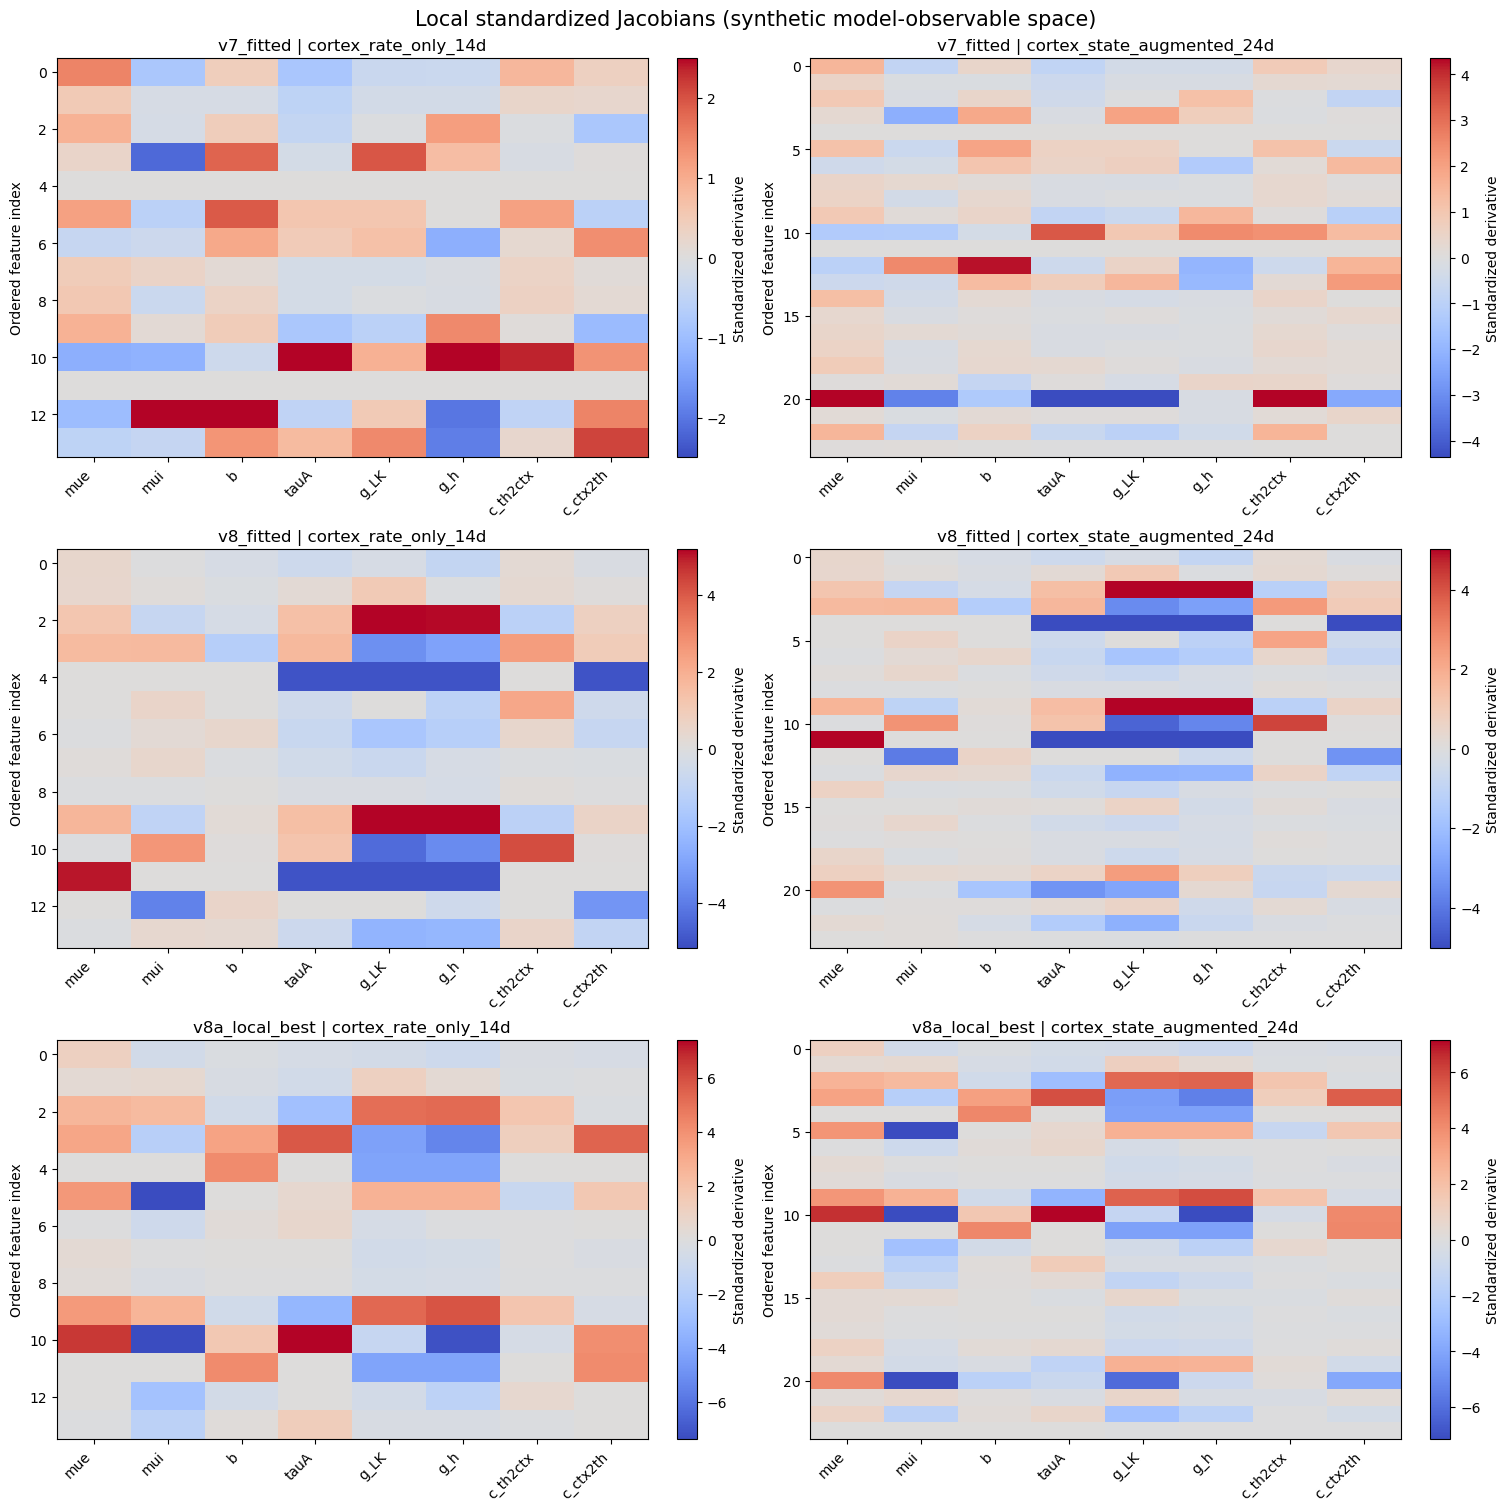

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15), constrained_layout=True)
centers = ["v7_fitted", "v8_fitted", "v8a_local_best"]
schemas = ["cortex_rate_only_14d", "cortex_state_augmented_24d"]
for row_index, center in enumerate(centers):
    for column_index, schema in enumerate(schemas):
        matrix = local_analysis["matrices"][(center, schema)]
        limit = np.nanpercentile(np.abs(matrix), 98)
        image = axes[row_index, column_index].imshow(
            matrix, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit
        )
        axes[row_index, column_index].set_title(f"{center} | {schema}")
        axes[row_index, column_index].set_xticks(range(8), PARAMETER_NAMES, rotation=45, ha="right")
        axes[row_index, column_index].set_ylabel("Ordered feature index")
        fig.colorbar(image, ax=axes[row_index, column_index], label="Standardized derivative")
fig.suptitle("Local standardized Jacobians (synthetic model-observable space)", fontsize=15)
fig.savefig(FIGURE_DIR / "local_jacobians.png", dpi=180)
fig.savefig(FIGURE_DIR / "local_jacobians.svg")
plt.show()

### Singular values and parameter sensitivity

The dashed line is the pre-frozen relative singular-value threshold. The
sensitivity norm summarizes the length of one Jacobian column; it depends on
the declared feature scaling and should be compared within this contract, not
read as a physical unit. A weak column or a pair of nearly parallel columns
signals a possible local ambiguity.

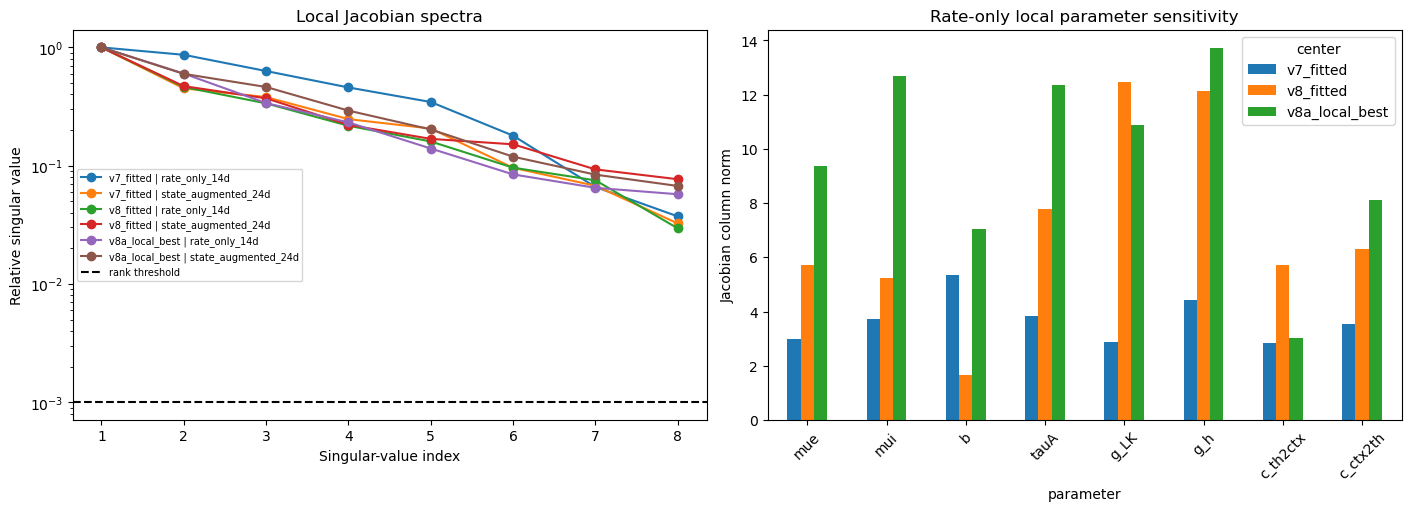

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for _, row in rank_table.iterrows():
    relative = [row[f"relative_singular_value_{i}"] for i in range(1, 9)]
    axes[0].semilogy(range(1, 9), relative, marker="o", label=f"{row['center']} | {row['schema'].replace('cortex_', '')}")
axes[0].axhline(RELATIVE_SINGULAR_VALUE_THRESHOLD, color="black", ls="--", label="rank threshold")
axes[0].set(xlabel="Singular-value index", ylabel="Relative singular value", title="Local Jacobian spectra")
axes[0].legend(fontsize=7)

rate_sensitivity = sensitivity_table[sensitivity_table["schema"] == "cortex_rate_only_14d"]
pivot = rate_sensitivity.pivot(index="parameter", columns="center", values="sensitivity_norm").loc[list(PARAMETER_NAMES)]
pivot.plot.bar(ax=axes[1])
axes[1].set(ylabel="Jacobian column norm", title="Rate-only local parameter sensitivity")
axes[1].tick_params(axis="x", rotation=45)
fig.savefig(FIGURE_DIR / "singular_values_and_sensitivity.png", dpi=180)
fig.savefig(FIGURE_DIR / "singular_values_and_sensitivity.svg")
plt.show()

### Targeted confounding and cross-center direction consistency

Cosine values near +1 or -1 indicate locally parallel or anti-parallel response
directions. This explicitly audits `g_LK` versus `g_h` and `c_th2ctx` versus
`c_ctx2th`. Negative cross-center cosines show that a parameter's local feature
direction can reverse across regimes, warning against extrapolating one local
Jacobian to the entire prior.

In [10]:
target_pairs = confounding_table[
    ((confounding_table["parameter_a"] == "g_LK") & (confounding_table["parameter_b"] == "g_h"))
    | ((confounding_table["parameter_a"] == "c_th2ctx") & (confounding_table["parameter_b"] == "c_ctx2th"))
].copy()
weakest = (
    sensitivity_table.sort_values(["center", "schema", "sensitivity_norm"])
    .groupby(["center", "schema"], as_index=False)
    .head(3)
)
inconsistent = direction_table.sort_values("sensitivity_direction_cosine").head(12)
display(target_pairs)
display(weakest)
display(inconsistent)

,center,schema,parameter_a,parameter_b,jacobian_column_cosine
22,v7_fitted,cortex_rate_only_14d,g_LK,g_h,-0.121539
27,v7_fitted,cortex_rate_only_14d,c_th2ctx,c_ctx2th,0.271091
50,v7_fitted,cortex_state_augmented_24d,g_LK,g_h,-0.007931
55,v7_fitted,cortex_state_augmented_24d,c_th2ctx,c_ctx2th,-0.333927
78,v8_fitted,cortex_rate_only_14d,g_LK,g_h,0.984954
83,v8_fitted,cortex_rate_only_14d,c_th2ctx,c_ctx2th,-0.029862
106,v8_fitted,cortex_state_augmented_24d,g_LK,g_h,0.934162
111,v8_fitted,cortex_state_augmented_24d,c_th2ctx,c_ctx2th,-0.026344
134,v8a_local_best,cortex_rate_only_14d,g_LK,g_h,0.893844
139,v8a_local_best,cortex_rate_only_14d,c_th2ctx,c_ctx2th,0.086222


,center,schema,parameter,sensitivity_norm
6,v7_fitted,cortex_rate_only_14d,c_th2ctx,2.846132
4,v7_fitted,cortex_rate_only_14d,g_LK,2.886140
0,v7_fitted,cortex_rate_only_14d,mue,2.990635
15,v7_fitted,cortex_state_augmented_24d,c_ctx2th,4.284176
13,v7_fitted,cortex_state_augmented_24d,g_h,4.468064
9,v7_fitted,cortex_state_augmented_24d,mui,5.008512
18,v8_fitted,cortex_rate_only_14d,b,1.640112
17,v8_fitted,cortex_rate_only_14d,mui,5.229886
16,v8_fitted,cortex_rate_only_14d,mue,5.705248
26,v8_fitted,cortex_state_augmented_24d,b,2.413662


,schema,parameter,center_a,center_b,sensitivity_direction_cosine
3,cortex_rate_only_14d,mui,v7_fitted,v8_fitted,-0.864835
27,cortex_state_augmented_24d,mui,v7_fitted,v8_fitted,-0.626299
12,cortex_rate_only_14d,g_LK,v7_fitted,v8_fitted,-0.537869
21,cortex_rate_only_14d,c_ctx2th,v7_fitted,v8_fitted,-0.402785
5,cortex_rate_only_14d,mui,v8_fitted,v8a_local_best,-0.387828
13,cortex_rate_only_14d,g_LK,v7_fitted,v8a_local_best,-0.386452
8,cortex_rate_only_14d,b,v8_fitted,v8a_local_best,-0.383816
45,cortex_state_augmented_24d,c_ctx2th,v7_fitted,v8_fitted,-0.364459
19,cortex_rate_only_14d,c_th2ctx,v7_fitted,v8a_local_best,-0.340437
44,cortex_state_augmented_24d,c_th2ctx,v8_fitted,v8a_local_best,-0.329509


## 4. Checkpointed 64-point prior-wide diagnostic micro-bank

Because both schemas passed the basic numerical gate, a scrambled Sobol design
with fixed seed 20260727 is evaluated over the full V8a 8D box. Every completed
simulation is atomically checkpointed. The internal simulator seed remains 42.
All theta rows, failures, validity masks, runtimes, and reasons are retained.

This sample is too small to be a formal training bank and is not used to train
SNPE in this notebook.

In [11]:
rate_gate = local_stability_gate(local_results, "cortex_rate_only_14d")
augmented_gate = local_stability_gate(local_results, "cortex_state_augmented_24d")
assert rate_gate[0] and augmented_gate[0]
microbank = run_diagnostic_microbank(n_samples=64, reuse_checkpoint=True)

assert microbank["theta"].shape == (64, 8)
assert microbank["rate_x"].shape == (64, 14)
assert microbank["augmented_x"].shape == (64, 24)
assert np.allclose(microbank["augmented_x"][:, :14], microbank["rate_x"], rtol=0, atol=0, equal_nan=True)

microbank_summary = pd.DataFrame(
    [
        {
            "simulations": len(microbank["theta"]),
            "completed": int(microbank["completed"].sum()),
            "success": int(microbank["success"].sum()),
            "failed": int((~microbank["success"]).sum()),
            "rate_finite_rows": int(np.isfinite(microbank["rate_x"]).all(axis=1).sum()),
            "augmented_finite_rows": int(np.isfinite(microbank["augmented_x"]).all(axis=1).sum()),
            "runtime_s": float(np.nansum(microbank["runtime_s"])),
            "median_runtime_s": float(np.nanmedian(microbank["runtime_s"])),
        }
    ]
)
display(microbank_summary)

,simulations,completed,success,failed,rate_finite_rows,augmented_finite_rows,runtime_s,median_runtime_s
0,64,64,64,0,64,64,316.446529,4.880917


### Prior coverage and runtime/failure accounting

Each parameter panel shows normalized prior position, not a posterior sample.
The right panel reports runtime by Sobol index; failed rows would be retained
and marked rather than silently filtered.

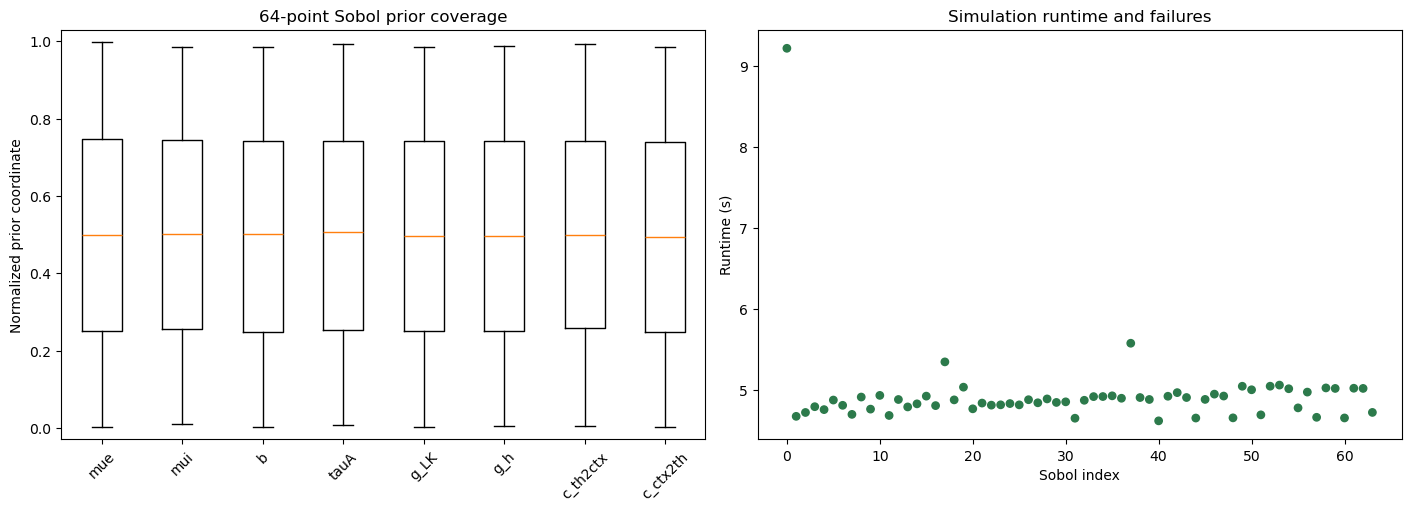

In [12]:
bounds = np.asarray(contract["bounds"], dtype=float)
theta_unit = (microbank["theta"] - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].boxplot([theta_unit[:, i] for i in range(8)], tick_labels=PARAMETER_NAMES, showfliers=True)
axes[0].set(ylabel="Normalized prior coordinate", title="64-point Sobol prior coverage", ylim=(-0.03, 1.03))
axes[0].tick_params(axis="x", rotation=45)
colors = np.where(microbank["success"], "#2c7a4b", "#b23a48")
axes[1].scatter(np.arange(64), microbank["runtime_s"], c=colors, s=28)
axes[1].set(xlabel="Sobol index", ylabel="Runtime (s)", title="Simulation runtime and failures")
fig.savefig(FIGURE_DIR / "microbank_coverage_and_runtime.png", dpi=180)
fig.savefig(FIGURE_DIR / "microbank_coverage_and_runtime.svg")
plt.show()

### Feature redundancy across the micro-bank

Spearman correlation detects monotonic co-variation but does not prove
deterministic equivalence. The 64-point matrix is a screening diagnostic:
correlation can reflect the Sobol design, nonlinear regimes, or common
parameter drivers. It does not justify deleting features without recovery and
held-out tests.

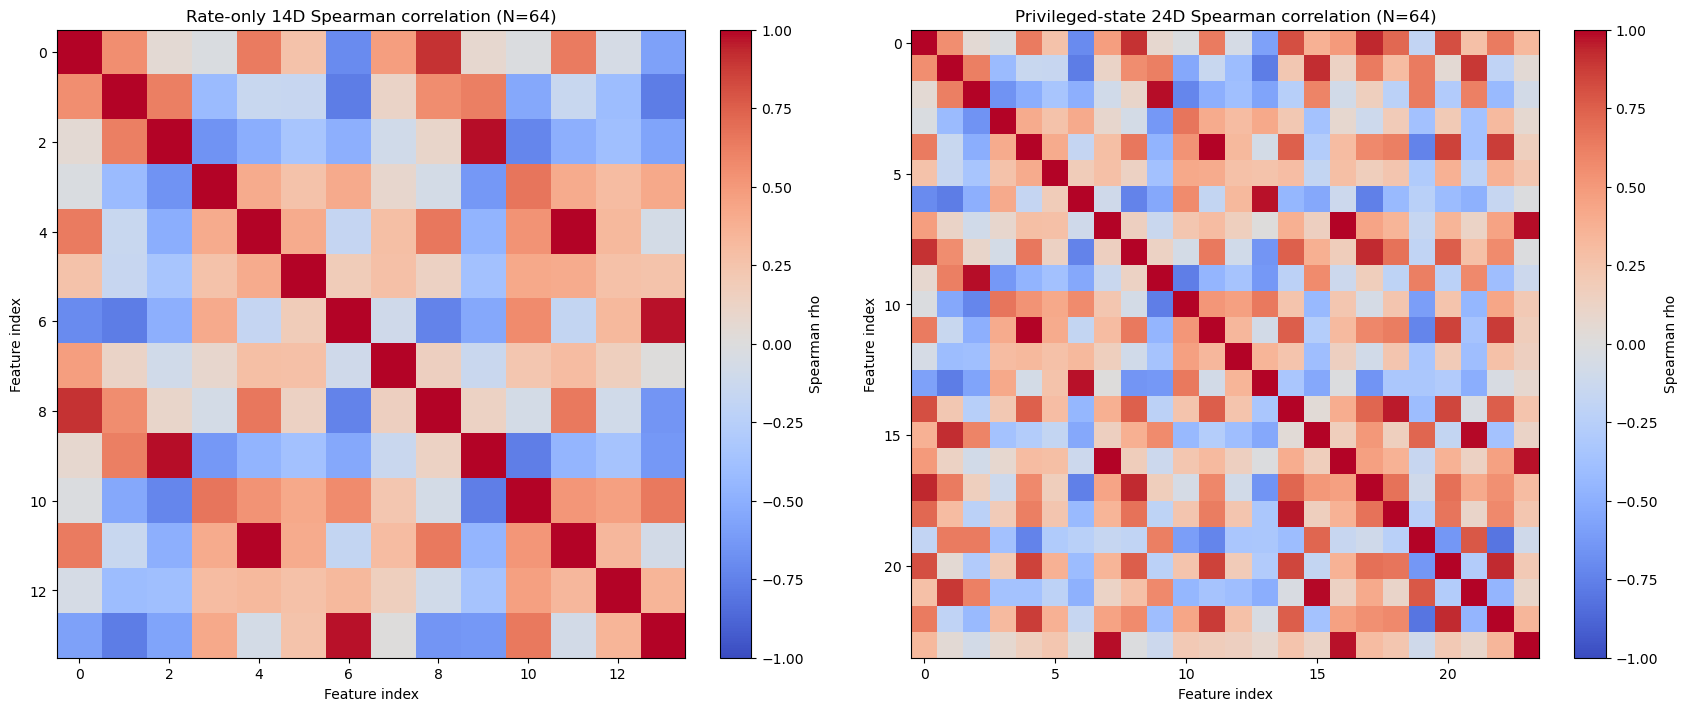

,schema,feature_a,feature_b,spearman_rho,valid_pair_n
8,augmented24,r_inh_mean_hz,I_mu_inh_mean_mV_per_ms,0.998764,64
6,augmented24,r_exc_so_peak_frequency_hz,r_inh_so_peak_frequency_hz,0.995724,64
1,rate14,r_exc_so_peak_frequency_hz,r_inh_so_peak_frequency_hz,0.995724,64
12,augmented24,I_mu_exc_std_mV_per_ms,effective_drive_std_mV_per_ms,0.988278,64
9,augmented24,r_inh_mean_hz,syn_mu_inh_on_exc_mean,0.981364,64
5,augmented24,r_exc_relative_so_power,r_inh_relative_so_power,0.981364,64
0,rate14,r_exc_relative_so_power,r_inh_relative_so_power,0.981364,64
13,augmented24,I_mu_inh_mean_mV_per_ms,syn_mu_inh_on_exc_mean,0.975824,64
7,augmented24,r_exc_spectral_entropy_0p5_20,r_inh_spectral_entropy_0p5_20,0.969460,64
2,rate14,r_exc_spectral_entropy_0p5_20,r_inh_spectral_entropy_0p5_20,0.969460,64


In [13]:
rate_corr, rate_pair_n = feature_redundancy(microbank["rate_x"], rate_names)
aug_corr, aug_pair_n = feature_redundancy(microbank["augmented_x"], augmented_names)
rate_corr.to_csv(OUTPUT_DIR / "diagnostic_microbank" / "rate_feature_spearman.csv")
aug_corr.to_csv(OUTPUT_DIR / "diagnostic_microbank" / "augmented_feature_spearman.csv")
rate_pair_n.to_csv(OUTPUT_DIR / "diagnostic_microbank" / "rate_valid_pair_counts.csv")
aug_pair_n.to_csv(OUTPUT_DIR / "diagnostic_microbank" / "augmented_valid_pair_counts.csv")

fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
for ax, corr, title in (
    (axes[0], rate_corr, "Rate-only 14D"),
    (axes[1], aug_corr, "Privileged-state 24D"),
):
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(f"{title} Spearman correlation (N=64)")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Feature index")
    fig.colorbar(image, ax=ax, label="Spearman rho")
fig.savefig(FIGURE_DIR / "microbank_feature_redundancy.png", dpi=180)
fig.savefig(FIGURE_DIR / "microbank_feature_redundancy.svg")
plt.show()

high_pairs = []
for schema, corr in (("rate14", rate_corr), ("augmented24", aug_corr)):
    for i in range(len(corr)):
        for j in range(i + 1, len(corr)):
            rho = float(corr.iloc[i, j])
            if np.isfinite(rho) and abs(rho) >= 0.9:
                high_pairs.append(
                    {"schema": schema, "feature_a": corr.index[i], "feature_b": corr.columns[j], "spearman_rho": rho, "valid_pair_n": 64}
                )
high_pairs = pd.DataFrame(high_pairs).sort_values("spearman_rho", key=np.abs, ascending=False)
high_pairs.to_csv(OUTPUT_DIR / "diagnostic_microbank" / "high_correlation_pairs.csv", index=False)
display(high_pairs)

## 5. Preflight decision

Passing conditions observed here:

- exact 8D V8a prior contract; V7/V8/V8a centers are inside it;
- 51/51 local simulations and 64/64 Sobol diagnostics completed;
- fixed 14D and 24D vectors with no NaN/Inf;
- all three local Jacobians reach rank 8 under the pre-frozen threshold.

Limits that remain:

- local direction reversals and `g_LK`/`g_h` near-parallelism occur in important regimes;
- peak-frequency features are quantized at 0.25 Hz;
- one fixed stochastic seed tests common-random-number sensitivity, not robustness to simulator noise;
- 64 prior points cannot establish global injectivity or synthetic recovery;
- privileged internal states cannot justify real-EEG inference.

**Decision:** conditional GO for a staged, checkpointed **Route-3 diagnostic
bank expansion and synthetic recovery protocol**. It is still a NO-GO for
SNPE/NPE training until seed robustness, scaling on a training split, global
collision checks, held-out theta recovery, and validation budget are frozen.

In [14]:
decision_table = pd.DataFrame(
    [
        {
            "question": "Cortex-rate-only locally full-rank at V7/V8/V8a?",
            "result": bool(rank_table[rank_table.schema == "cortex_rate_only_14d"]["full_local_rank"].all()),
            "interpretation": "Necessary local evidence only; not global recoverability.",
        },
        {
            "question": "Did privileged internal states increase effective rank?",
            "result": False,
            "interpretation": "Both schemas are rank 8; internal states improve conditioning at V8/V8a but not V7.",
        },
        {
            "question": "64-point prior-wide numerical stability?",
            "result": bool(microbank["success"].all()),
            "interpretation": "64/64 finite under one fixed simulator seed.",
        },
        {
            "question": "Allow staged diagnostic bank expansion next?",
            "result": True,
            "interpretation": "Conditional GO with checkpointing and explicit recovery design.",
        },
        {
            "question": "Allow SNPE training now?",
            "result": False,
            "interpretation": "No: global recovery, seed robustness, scaling, split, and calibration protocol remain unfrozen.",
        },
    ]
)
display(decision_table)

,question,result,interpretation
0,Cortex-rate-only locally full-rank at V7/V8/V8a?,True,Necessary local evidence only; not global reco...
1,Did privileged internal states increase effect...,False,Both schemas are rank 8; internal states impro...
2,64-point prior-wide numerical stability?,True,64/64 finite under one fixed simulator seed.
3,Allow staged diagnostic bank expansion next?,True,Conditional GO with checkpointing and explicit...
4,Allow SNPE training now?,False,"No: global recovery, seed robustness, scaling,..."


## 6. Artifact reload and validation

The final cell reloads JSON, CSV, and NPZ without pickle, verifies shapes,
feature order, finite masks, schema version, and the absence of object arrays.
It also writes a machine-readable validation report. This validates artifact
integrity, not scientific identifiability.

In [15]:
contract_reload = json.loads(Path(contract_paths["contract"]).read_text(encoding="utf-8"))
features_reload = pd.read_csv(contract_paths["features"])
heldout_reload = pd.read_csv(contract_paths["held_out"])
bank_path = Path(microbank["path"])
with np.load(bank_path, allow_pickle=False) as bank_reload:
    object_arrays = [name for name in bank_reload.files if bank_reload[name].dtype == object]
    assert not object_arrays
    assert bank_reload["theta"].shape == (64, 8)
    assert bank_reload["rate_x"].shape == (64, 14)
    assert bank_reload["augmented_x"].shape == (64, 24)
    assert list(bank_reload["parameter_names"]) == list(PARAMETER_NAMES)
    assert list(bank_reload["rate_feature_names"]) == rate_names
    assert list(bank_reload["augmented_feature_names"]) == augmented_names
    assert str(bank_reload["schema_version"].item()) == SCHEMA_VERSION
    assert np.isfinite(bank_reload["theta"]).all()
    assert np.isfinite(bank_reload["rate_x"]).all()
    assert np.isfinite(bank_reload["augmented_x"]).all()

validation_report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "schema_version": SCHEMA_VERSION,
    "contract_hash": contract_reload["contract_hash"],
    "parameter_dimension": 8,
    "rate_schema_dimension": 14,
    "augmented_schema_dimension": 24,
    "local_simulations": len(local_results),
    "local_failures": int((~local_runs["success"]).sum()),
    "local_effective_ranks": rank_table[["center", "schema", "effective_rank"]].to_dict("records"),
    "diagnostic_microbank_rows": 64,
    "diagnostic_microbank_failures": int((~microbank["success"]).sum()),
    "all_record_vectors_finite": bool(
        np.isfinite(microbank["rate_x"]).all() and np.isfinite(microbank["augmented_x"]).all()
    ),
    "npz_object_arrays": object_arrays,
    "snpe_training_authorized": False,
    "next_step_decision": "conditional GO for staged diagnostic bank expansion; SNPE remains NO-GO",
}
(OUTPUT_DIR / "validation_report.json").write_text(
    json.dumps(validation_report, indent=2), encoding="utf-8"
)
assert len(features_reload[features_reload.schema == "cortex_rate_only_14d"]) == 14
assert len(features_reload[features_reload.schema == "cortex_state_augmented_24d"]) == 24
assert len(heldout_reload) == len(HELD_OUT_DIAGNOSTICS)
print(json.dumps(validation_report, indent=2))

{
  "created_utc": "2026-07-27T17:24:56.965146+00:00",
  "schema_version": "route3-preflight-v1",
  "contract_hash": "0d9fac3ceafbf7525a2ea9a4a2a33094e27fbb0e15eb3bc14177849545d6d345",
  "parameter_dimension": 8,
  "rate_schema_dimension": 14,
  "augmented_schema_dimension": 24,
  "local_simulations": 51,
  "local_failures": 0,
  "local_effective_ranks": [
    {
      "center": "v7_fitted",
      "schema": "cortex_rate_only_14d",
      "effective_rank": 8
    },
    {
      "center": "v7_fitted",
      "schema": "cortex_state_augmented_24d",
      "effective_rank": 8
    },
    {
      "center": "v8_fitted",
      "schema": "cortex_rate_only_14d",
      "effective_rank": 8
    },
    {
      "center": "v8_fitted",
      "schema": "cortex_state_augmented_24d",
      "effective_rank": 8
    },
    {
      "center": "v8a_local_best",
      "schema": "cortex_rate_only_14d",
      "effective_rank": 8
    },
    {
      "center": "v8a_local_best",
      "schema": "cortex_state_augmented_24d"